In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()

RAW_PATH = "../data/raw/"
PROCESSED_PATH = "../data/processed/"

In [16]:
df = pd.read_csv(os.path.join(RAW_PATH, "/Users/sannabatra/energy-demand-forecasting/data/raw/PJME_hourly.csv"))
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (145366, 2)

Columns: ['Datetime', 'PJME_MW']

First 5 rows:


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [17]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.set_index("Datetime")
df = df.sort_index()

print("Date range:", df.index.min(), "→", df.index.max())
print("Total hours:", len(df))
print("Dtype:", df.dtypes)

Date range: 2002-01-01 01:00:00 → 2018-08-03 00:00:00
Total hours: 145366
Dtype: PJME_MW    float64
dtype: object


In [18]:
print("=== Basic Info ===")
print(df.info())

print("\n=== Descriptive Statistics ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Basic Info ===
<class 'pandas.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB
None

=== Descriptive Statistics ===
             PJME_MW
count  145366.000000
mean    32080.222831
std      6464.012166
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000

=== Missing Values ===
PJME_MW    0
dtype: int64


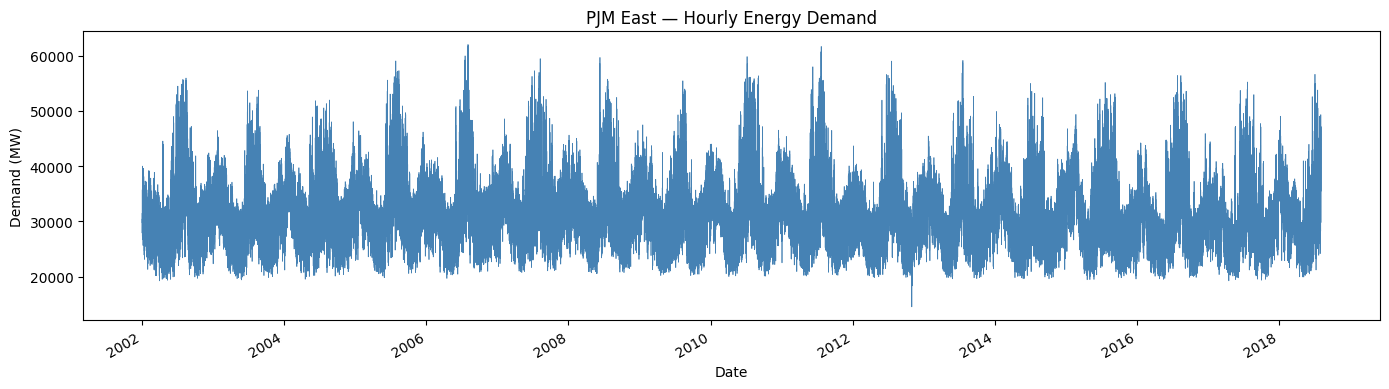

In [19]:
fig, ax = plt.subplots(figsize=(14, 4))
df["PJME_MW"].plot(ax=ax, linewidth=0.5, color="steelblue")
ax.set_title("PJM East — Hourly Energy Demand")
ax.set_ylabel("Demand (MW)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig("../reports/figures/01_raw_series.png", dpi=150)
plt.show()

In [20]:
df.to_csv("../data/processed/pjme_clean.csv")
print("Saved to data/processed/pjme_clean.csv")
print("Final shape:", df.shape)

Saved to data/processed/pjme_clean.csv
Final shape: (145366, 1)
